In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import distance
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# bulk
bulk = pd.read_csv("../../data/bulk_data/Finotello_2019/final_data/Finotello_TPM_data.csv", index_col=0)
bulk

,UBE2Q2P2,SSX9,CXorf67,EFCAB8,SPATA31B1P,SDR16C6P,GTPBP6,EFCAB12,A1BG,A1CF,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,TPTEP1
pbmc_1,0.000000,0.000000,0.118865,0.000000,0.0,0.000000,57.280197,0.252188,10.863071,0.000000,...,3.477319,3.44931,6.36162,16.473360,0.426082,7.471390,327.737590,17.070511,14.530079,5.155380
pbmc_10,0.081115,0.000000,0.086782,0.000000,0.0,0.000000,72.275326,0.095742,14.785649,0.000000,...,3.712750,3.55546,5.50518,14.924620,0.222251,6.381709,442.838401,12.744583,9.246122,13.326484
pbmc_12,0.000000,0.000000,0.188464,0.031570,0.0,0.000000,50.997427,0.100608,7.492537,0.000000,...,2.937518,3.70517,7.47136,16.866000,0.409656,9.498991,364.599060,18.526458,13.210396,19.452058
pbmc_2,0.000000,0.000000,0.094006,0.004499,0.0,0.000000,60.604133,0.050183,15.827180,0.000000,...,2.454242,1.86107,3.35811,13.062773,0.405473,5.799880,219.376050,12.623465,5.652651,13.401427
pbmc_4,0.059691,0.212565,0.496705,0.346400,0.0,0.287881,104.405300,0.984864,10.540150,0.269025,...,2.885740,3.78000,9.81738,30.148749,4.520060,12.566580,250.918200,34.720530,12.323414,45.098055
pbmc_5,0.613015,0.000000,0.196090,0.385828,0.0,0.000000,102.156500,0.513702,6.647064,0.000000,...,3.758755,4.24224,10.62830,30.756770,1.147440,11.558017,372.000060,37.414882,13.270457,17.063871
pbmc_6,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,52.882543,0.176120,9.519831,0.000000,...,4.256100,3.51173,4.68182,15.245900,0.213477,7.536230,458.764880,15.674012,9.396960,12.847275
pbmc_7,0.000000,0.000000,0.165406,0.048187,0.0,0.000000,61.837424,0.044789,9.196318,0.000000,...,2.472849,2.89564,5.98077,14.535830,0.520593,5.990022,290.344501,16.399724,10.407555,15.988808
pbmc_9,0.000000,0.000000,0.157926,0.041571,0.0,0.000000,47.350889,0.098357,9.537508,0.000000,...,3.869803,3.45627,5.65227,14.146395,0.508913,7.500722,380.691001,14.024112,8.513980,8.728245


In [3]:
# pseudobulks
def read_pseudobulks_from_directory(pseudobulk_directory):
    files = [f for f in Path(pseudobulk_directory).glob("*_pseudobulks.csv")]
    dfs = []

    for path in files:
        df = pd.read_csv(path, index_col=0)
        df["sample_number"] = df.index
        df.reset_index(drop=True, inplace=True)
        df["sample"] = path.stem
        df.index = df["sample"]
        dfs.append(df)

    combined = pd.concat(dfs)
    combined["no_cells"] = combined.index.to_series().str.split('_').str[2]
    combined["no_cells"] = combined["no_cells"].str.split("c", expand=True)[0] 
    return combined

In [4]:
pseudobulks = read_pseudobulks_from_directory("/ceph/ibmi/it/projects/ML_BI/17_Deconv_benchmark/runs_for_grood_paper/complete_set_of_runs/pseudobulk_data/Hao_pseudobulks_for_convolution/")
pseudobulks.index = pseudobulks['sample_number'].astype(str) + "_" + pseudobulks.index.astype(str)
pseudobulks

,TIA1,CPSF1,ATF3,ARG2,ADCK2,KIAA0232,SUSD3,URGCP,AP2S1,BTBD1,...,CXCR5,TLN1,FDPS,SLC17A9,FAM114A1,ATAD1,EPHB3,sample_number,sample,no_cells
pbmc_1_Hao-2_notarget_200cells_pseudobulks,42.861592,12.382238,11.429758,0.952480,9.524798,22.859516,50.481431,6.667359,160.969091,21.907036,...,4.762399,312.413384,51.433911,9.524798,0.952480,30.479355,1.904960,pbmc_1,Hao-2_notarget_200cells_pseudobulks,200
pbmc_10_Hao-2_notarget_200cells_pseudobulks,35.646778,10.318804,23.451828,0.000000,8.442658,25.327974,29.080266,11.256877,224.199472,20.637608,...,2.814219,323.635221,52.532094,2.814219,1.876146,32.832559,2.814219,pbmc_10,Hao-2_notarget_200cells_pseudobulks,200
pbmc_12_Hao-2_notarget_200cells_pseudobulks,41.674119,13.023162,19.100638,0.000000,11.286741,26.046324,24.309903,1.736422,250.912924,18.232427,...,7.813897,356.834642,65.115811,2.604632,0.000000,39.937697,0.000000,pbmc_12,Hao-2_notarget_200cells_pseudobulks,200
pbmc_2_Hao-2_notarget_200cells_pseudobulks,37.398305,12.466102,16.301825,0.000000,12.466102,28.767927,36.439374,5.753585,211.923730,19.178618,...,6.712516,331.790094,60.412647,9.589309,1.917862,27.808996,0.000000,pbmc_2,Hao-2_notarget_200cells_pseudobulks,200
pbmc_4_Hao-2_notarget_200cells_pseudobulks,57.764428,10.664202,13.330253,0.888684,14.218936,24.883138,26.660505,7.998152,237.278496,22.217088,...,7.998152,338.588415,75.538098,7.109468,3.554734,32.881290,0.000000,pbmc_4,Hao-2_notarget_200cells_pseudobulks,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pbmc_4_Hao-2_notarget_10000cells_pseudobulks,46.818281,14.179352,14.232194,0.193755,11.114498,33.149739,28.446774,7.574064,223.082593,23.990406,...,7.574064,332.166722,64.520453,4.491596,2.589273,30.313868,0.510809,pbmc_4,Hao-2_notarget_10000cells_pseudobulks,10000
pbmc_5_Hao-2_notarget_10000cells_pseudobulks,49.359275,14.259700,17.446225,0.254922,11.423693,37.282345,25.906450,7.233412,241.745733,24.376918,...,4.795720,357.846778,67.012625,4.636394,2.469557,30.160461,0.382383,pbmc_5,Hao-2_notarget_10000cells_pseudobulks,10000
pbmc_6_Hao-2_notarget_10000cells_pseudobulks,49.224342,13.415255,15.940480,0.385798,10.258725,35.809087,27.093555,7.400311,213.714663,23.147892,...,6.681323,341.220966,61.675102,4.559433,2.472616,29.723997,0.403334,pbmc_6,Hao-2_notarget_10000cells_pseudobulks,10000
pbmc_7_Hao-2_notarget_10000cells_pseudobulks,48.971288,14.325730,14.526090,0.233753,11.453905,35.163155,25.762938,6.879022,225.187782,23.458800,...,9.066283,337.389301,64.048367,5.092480,2.471105,29.786832,0.500900,pbmc_7,Hao-2_notarget_10000cells_pseudobulks,10000


In [5]:
# subset such that they have the same gene sets
def prepare_data(bulk_df, pb_df):
    # drop non unique gene symbols
    bulk_df = bulk_df.loc[:, ~bulk_df.columns.duplicated()]
    pb_df = pb_df.loc[:, ~pb_df.columns.duplicated()]
    # drop nans
    bulk_df = bulk_df.dropna(axis=1, how='all')
    pb_df = pb_df.dropna(axis=1, how='all')
    # common genes
    common_genes = pb_df.columns.intersection(bulk_df.columns)
    bulk_df = bulk_df[common_genes]
    pb_df = pb_df[common_genes]
    # normalize subset to CPM
    bulk_df = bulk_df.div(bulk_df.sum(axis=1), axis=0) * 1e6
    pb_df = pb_df.div(pb_df.sum(axis=1), axis=0) * 1e6
    # sort the two
    bulk_df.sort_index(inplace=True)
    pb_df.sort_index(inplace=True)
    return bulk_df, pb_df

In [6]:
bulk, pseudobulks = prepare_data(bulk_df=bulk, pb_df=pseudobulks)
bulk

,TIA1,CPSF1,ATF3,ARG2,ADCK2,KIAA0232,SUSD3,URGCP,AP2S1,BTBD1,...,POLE2,TRAF7,TFPI,CXCR5,TLN1,FDPS,SLC17A9,FAM114A1,ATAD1,EPHB3
pbmc_1,25.325452,37.874540,2.162303,5.599081,25.877627,11.062827,54.149672,9.367002,155.692969,38.182787,...,0.578971,31.854943,0.067158,16.228553,207.102356,68.552487,2.616050,1.320320,12.789537,1.348888
pbmc_10,20.765540,39.233746,2.098754,4.976475,22.596823,7.517740,41.323537,7.826899,222.486926,29.921283,...,0.543297,36.303660,0.219949,16.199860,183.237764,57.257433,1.644569,2.600476,8.357973,0.303797
pbmc_12,24.733533,38.499515,2.226980,4.972446,24.287005,10.561804,25.240511,8.042596,164.903458,38.694400,...,0.692101,31.050311,0.308981,11.138216,219.862069,61.659080,1.806667,1.012059,9.729387,0.316179
pbmc_2,15.743174,28.920634,1.297504,1.914162,24.053248,7.516014,51.752670,7.882819,200.614448,23.725106,...,0.576127,24.194873,0.153136,9.303600,110.136076,50.957848,2.193155,1.483233,7.637133,0.627986
pbmc_4,44.747911,128.285790,8.168098,4.268813,18.970988,11.643244,71.945292,14.770916,141.933372,39.003358,...,1.503667,35.888299,0.741224,14.174964,149.144497,71.990186,32.672998,1.608640,14.307543,0.323348
pbmc_5,51.835665,104.904194,4.843142,7.008541,19.950153,16.851481,23.964265,9.556684,148.127049,44.248703,...,0.807215,41.000579,0.321678,9.368614,224.784931,70.043444,21.341880,2.404661,14.923808,0.545446
pbmc_6,25.844093,36.722740,2.838669,5.216962,23.444624,9.341900,39.300743,7.876454,207.998209,37.046984,...,1.150856,36.021903,0.333766,12.140995,208.650984,62.160322,3.382983,0.836044,10.824376,0.813431
pbmc_7,19.822256,27.040209,5.818361,4.279879,25.833651,8.744773,32.370442,7.612516,202.768716,34.598989,...,0.232781,30.693858,0.273611,8.547451,161.846998,71.239604,2.459625,0.639662,11.909510,0.368394
pbmc_9,19.999899,29.875233,5.686882,4.844763,22.363958,9.007545,22.424400,6.858336,203.564800,34.627970,...,0.718987,30.437226,0.169329,7.790991,176.139083,63.713431,1.712655,0.964724,10.729741,0.239545


In [7]:
pseudobulks

,TIA1,CPSF1,ATF3,ARG2,ADCK2,KIAA0232,SUSD3,URGCP,AP2S1,BTBD1,...,POLE2,TRAF7,TFPI,CXCR5,TLN1,FDPS,SLC17A9,FAM114A1,ATAD1,EPHB3
pbmc_10_Hao-2_notarget_10000cells_pseudobulks,47.679767,13.830772,17.161076,0.363968,10.991824,36.596951,29.626970,6.697005,222.857415,23.020956,...,0.782531,20.837150,0.509555,5.113746,338.216973,61.346754,4.404009,2.875345,28.717050,0.600547
pbmc_10_Hao-2_notarget_1000cells_pseudobulks,48.133121,15.190301,18.667598,0.549047,10.431893,40.629479,29.099492,5.856501,220.350867,25.439178,...,0.366031,20.497755,0.549047,5.490470,338.762005,64.421516,4.758407,2.196188,28.367429,0.732063
pbmc_10_Hao-2_notarget_100cells_pseudobulks,46.801713,8.139428,24.418285,2.034857,14.244000,28.487999,32.557714,10.174286,203.485710,24.418285,...,0.000000,12.209143,0.000000,2.034857,301.158851,69.185141,8.139428,2.034857,18.313714,2.034857
pbmc_10_Hao-2_notarget_2000cells_pseudobulks,48.705297,15.220405,16.235099,0.092245,10.608161,38.004891,33.946116,7.287346,223.509346,23.799179,...,0.830204,21.585302,0.922449,5.534693,352.098709,62.080805,3.044081,2.859591,28.503668,0.645714
pbmc_10_Hao-2_notarget_200cells_pseudobulks,35.646778,10.318804,23.451828,0.000000,8.442658,25.327974,29.080266,11.256877,224.199472,20.637608,...,0.000000,16.885316,1.876146,2.814219,323.635221,52.532094,2.814219,1.876146,32.832559,2.814219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pbmc_9_Hao-2_notarget_100cells_pseudobulks,53.403203,10.013100,20.026201,1.668850,21.695051,33.377002,31.708151,3.337700,287.042214,11.681951,...,0.000000,26.701601,0.000000,8.344250,352.127367,71.760553,5.006550,6.675400,33.377002,1.668850
pbmc_9_Hao-2_notarget_2000cells_pseudobulks,49.987685,15.065840,16.533794,0.154521,9.503068,32.604023,25.727819,4.481122,251.097334,25.341516,...,0.540825,21.555740,0.927129,5.253729,342.110460,61.808575,5.253729,2.858647,27.968380,0.154521
pbmc_9_Hao-2_notarget_200cells_pseudobulks,56.790307,20.507611,8.676297,0.000000,9.465051,33.127679,24.451382,3.943771,246.091328,20.507611,...,0.000000,39.437713,0.788754,7.098788,373.869518,64.677849,2.366263,3.155017,34.705187,0.000000
pbmc_9_Hao-2_notarget_5000cells_pseudobulks,50.003078,14.423371,18.006050,0.154426,11.952558,32.923583,25.325833,7.103587,249.428570,23.781575,...,0.741244,22.546168,1.019210,6.053492,344.523985,66.001592,4.756315,2.563468,27.827531,0.710359


In [8]:
# # re normalize to CPM
# def normalize_to_cpm(df): 
#     # in-place modification :D
#     #df[:] = df.div(df.sum(axis=1), axis=0) * 1e6 # already done before
#     df[:] = np.log2(df + 1)

# normalize_to_cpm(bulk)
# normalize_to_cpm(pseudobulks)

In [9]:
samples = bulk.index.tolist()
pseudobulks

,TIA1,CPSF1,ATF3,ARG2,ADCK2,KIAA0232,SUSD3,URGCP,AP2S1,BTBD1,...,POLE2,TRAF7,TFPI,CXCR5,TLN1,FDPS,SLC17A9,FAM114A1,ATAD1,EPHB3
pbmc_10_Hao-2_notarget_10000cells_pseudobulks,47.679767,13.830772,17.161076,0.363968,10.991824,36.596951,29.626970,6.697005,222.857415,23.020956,...,0.782531,20.837150,0.509555,5.113746,338.216973,61.346754,4.404009,2.875345,28.717050,0.600547
pbmc_10_Hao-2_notarget_1000cells_pseudobulks,48.133121,15.190301,18.667598,0.549047,10.431893,40.629479,29.099492,5.856501,220.350867,25.439178,...,0.366031,20.497755,0.549047,5.490470,338.762005,64.421516,4.758407,2.196188,28.367429,0.732063
pbmc_10_Hao-2_notarget_100cells_pseudobulks,46.801713,8.139428,24.418285,2.034857,14.244000,28.487999,32.557714,10.174286,203.485710,24.418285,...,0.000000,12.209143,0.000000,2.034857,301.158851,69.185141,8.139428,2.034857,18.313714,2.034857
pbmc_10_Hao-2_notarget_2000cells_pseudobulks,48.705297,15.220405,16.235099,0.092245,10.608161,38.004891,33.946116,7.287346,223.509346,23.799179,...,0.830204,21.585302,0.922449,5.534693,352.098709,62.080805,3.044081,2.859591,28.503668,0.645714
pbmc_10_Hao-2_notarget_200cells_pseudobulks,35.646778,10.318804,23.451828,0.000000,8.442658,25.327974,29.080266,11.256877,224.199472,20.637608,...,0.000000,16.885316,1.876146,2.814219,323.635221,52.532094,2.814219,1.876146,32.832559,2.814219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pbmc_9_Hao-2_notarget_100cells_pseudobulks,53.403203,10.013100,20.026201,1.668850,21.695051,33.377002,31.708151,3.337700,287.042214,11.681951,...,0.000000,26.701601,0.000000,8.344250,352.127367,71.760553,5.006550,6.675400,33.377002,1.668850
pbmc_9_Hao-2_notarget_2000cells_pseudobulks,49.987685,15.065840,16.533794,0.154521,9.503068,32.604023,25.727819,4.481122,251.097334,25.341516,...,0.540825,21.555740,0.927129,5.253729,342.110460,61.808575,5.253729,2.858647,27.968380,0.154521
pbmc_9_Hao-2_notarget_200cells_pseudobulks,56.790307,20.507611,8.676297,0.000000,9.465051,33.127679,24.451382,3.943771,246.091328,20.507611,...,0.000000,39.437713,0.788754,7.098788,373.869518,64.677849,2.366263,3.155017,34.705187,0.000000
pbmc_9_Hao-2_notarget_5000cells_pseudobulks,50.003078,14.423371,18.006050,0.154426,11.952558,32.923583,25.325833,7.103587,249.428570,23.781575,...,0.741244,22.546168,1.019210,6.053492,344.523985,66.001592,4.756315,2.563468,27.827531,0.710359


In [10]:
def calculate_ccc(p,q):
    cor = np.corrcoef(p, q)[0,1]
    mean_p = np.mean(p)
    mean_q = np.mean(q)
    var_p = np.var(p)
    var_q = np.var(q)
    sd_p = np.std(p)
    sd_q = np.std(q)
    num = 2 * cor * sd_p * sd_q
    denom = var_p + var_q + (mean_p - mean_q)**2
    return (num / denom)

In [11]:
metric_summary = pd.DataFrame(columns=["sample_id", "ncells", "metric", "value"])
metric_summary

,sample_id,ncells,metric,value


In [12]:
ncells = pseudobulks.copy()
ncells['ncells'] = ncells.index.to_series().str.split('_',expand=True)[4]
ncells['ncells'] = ncells['ncells'].str.split('c', expand=True)[0]

samples = pseudobulks.index.tolist()

for sample in samples:

    bulk_id = sample.split('_Hao')[0]
    sample_bulk = bulk.loc[bulk_id]
    matched_pseudobulk = pseudobulks.loc[sample]
    matched_ncells = ncells.loc[sample,'ncells']

    row1 = np.array(sample_bulk)
    row2 = np.array(matched_pseudobulk)
    # Pearson  
    pearson = pearsonr(row1, row2)
    metric_summary.loc[len(metric_summary)] = [sample, matched_ncells, "Pearson", pearson.statistic]
    # Spearman
    spearman = spearmanr(row1, row2)
    metric_summary.loc[len(metric_summary)] = [sample, matched_ncells, "Spearman", spearman.statistic]
    # 1 - JSD
    p = row1 + 1e-10
    q = row2 + 1e-10
    p = p / p.sum()
    q = q / q.sum()
    jsd = distance.jensenshannon(p=p, q=q)
    metric_summary.loc[len(metric_summary)] = [sample, matched_ncells, "1-JSD", 1-jsd]
    # CCC
    ccc = calculate_ccc(row1, row2)
    metric_summary.loc[len(metric_summary)] = [sample, matched_ncells, "CCC", ccc]


In [13]:
metric_summary = pd.DataFrame(metric_summary)
metric_summary

,sample_id,ncells,metric,value
0,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,Pearson,0.586666
1,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,Spearman,0.874068
2,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,1-JSD,0.709120
3,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,CCC,0.571593
4,pbmc_10_Hao-2_notarget_1000cells_pseudobulks,1000,Pearson,0.583781
...,...,...,...,...
247,pbmc_9_Hao-2_notarget_5000cells_pseudobulks,5000,CCC,0.455527
248,pbmc_9_Hao-2_notarget_500cells_pseudobulks,500,Pearson,0.442708
249,pbmc_9_Hao-2_notarget_500cells_pseudobulks,500,Spearman,0.868347
250,pbmc_9_Hao-2_notarget_500cells_pseudobulks,500,1-JSD,0.676450


In [15]:
metric_summary['ncells'] = pd.to_numeric(metric_summary['ncells'])
order = sorted(metric_summary['ncells'].unique())
metric_summary['ncells'] = pd.Categorical(metric_summary['ncells'], categories=order, ordered=True)
metric_summary = metric_summary.loc[metric_summary['metric'] != 'Spearman']
metric_summary.replace({'Pearson' : 'PCC'}, inplace=True)
metric_summary

/tmp/ipykernel_1519276/204299416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_summary['ncells'] = pd.to_numeric(metric_summary['ncells'])
/tmp/ipykernel_1519276/204299416.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_summary['ncells'] = pd.Categorical(metric_summary['ncells'], categories=order, ordered=True)


,sample_id,ncells,metric,value
0,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,PCC,0.586666
2,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,1-JSD,0.709120
3,pbmc_10_Hao-2_notarget_10000cells_pseudobulks,10000,CCC,0.571593
4,pbmc_10_Hao-2_notarget_1000cells_pseudobulks,1000,PCC,0.583781
6,pbmc_10_Hao-2_notarget_1000cells_pseudobulks,1000,1-JSD,0.706380
...,...,...,...,...
246,pbmc_9_Hao-2_notarget_5000cells_pseudobulks,5000,1-JSD,0.680730
247,pbmc_9_Hao-2_notarget_5000cells_pseudobulks,5000,CCC,0.455527
248,pbmc_9_Hao-2_notarget_500cells_pseudobulks,500,PCC,0.442708
250,pbmc_9_Hao-2_notarget_500cells_pseudobulks,500,1-JSD,0.676450


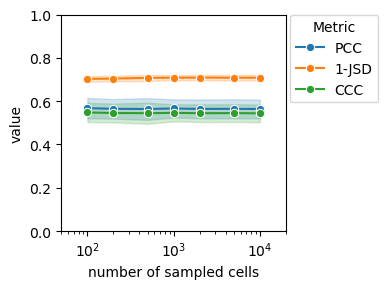

In [21]:
plt.figure(figsize=(4,3))
sns.lineplot(data=metric_summary, x='ncells', y='value', hue='metric', marker='o', errorbar="sd")

plt.xlabel('number of sampled cells')
plt.ylabel('value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Metric')
plt.ylim(0.0, 1.0)
plt.xlim(50, 2e4)
plt.xscale("log")
plt.tight_layout()
plt.savefig("SI_Figure_1D.svg", dpi=600)
plt.show()